In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA


sns.set_theme(style="whitegrid", context="notebook")

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Country-data.csv')

print(f'Shape of the dataset: {df.shape}')

Shape of the dataset: (167, 10)


In [ ]:
# check null values

pd.DataFrame({
    'Columns': df.columns,
    'Null Values': df.isnull().sum()
    }).reset_index(drop = True)

,Columns,Null Values
0,country,0
1,child_mort,0
2,exports,0
3,health,0
4,imports,0
5,income,0
6,inflation,0
7,life_expec,0
8,total_fer,0
9,gdpp,0


In [ ]:
# check data types

pd.DataFrame({
    'Columns': df.columns,
    'Data Types': df.dtypes
}).reset_index(drop = True)

,Columns,Data Types
0,country,object
1,child_mort,float64
2,exports,float64
3,health,float64
4,imports,float64
5,income,int64
6,inflation,float64
7,life_expec,float64
8,total_fer,float64
9,gdpp,int64


# EDA

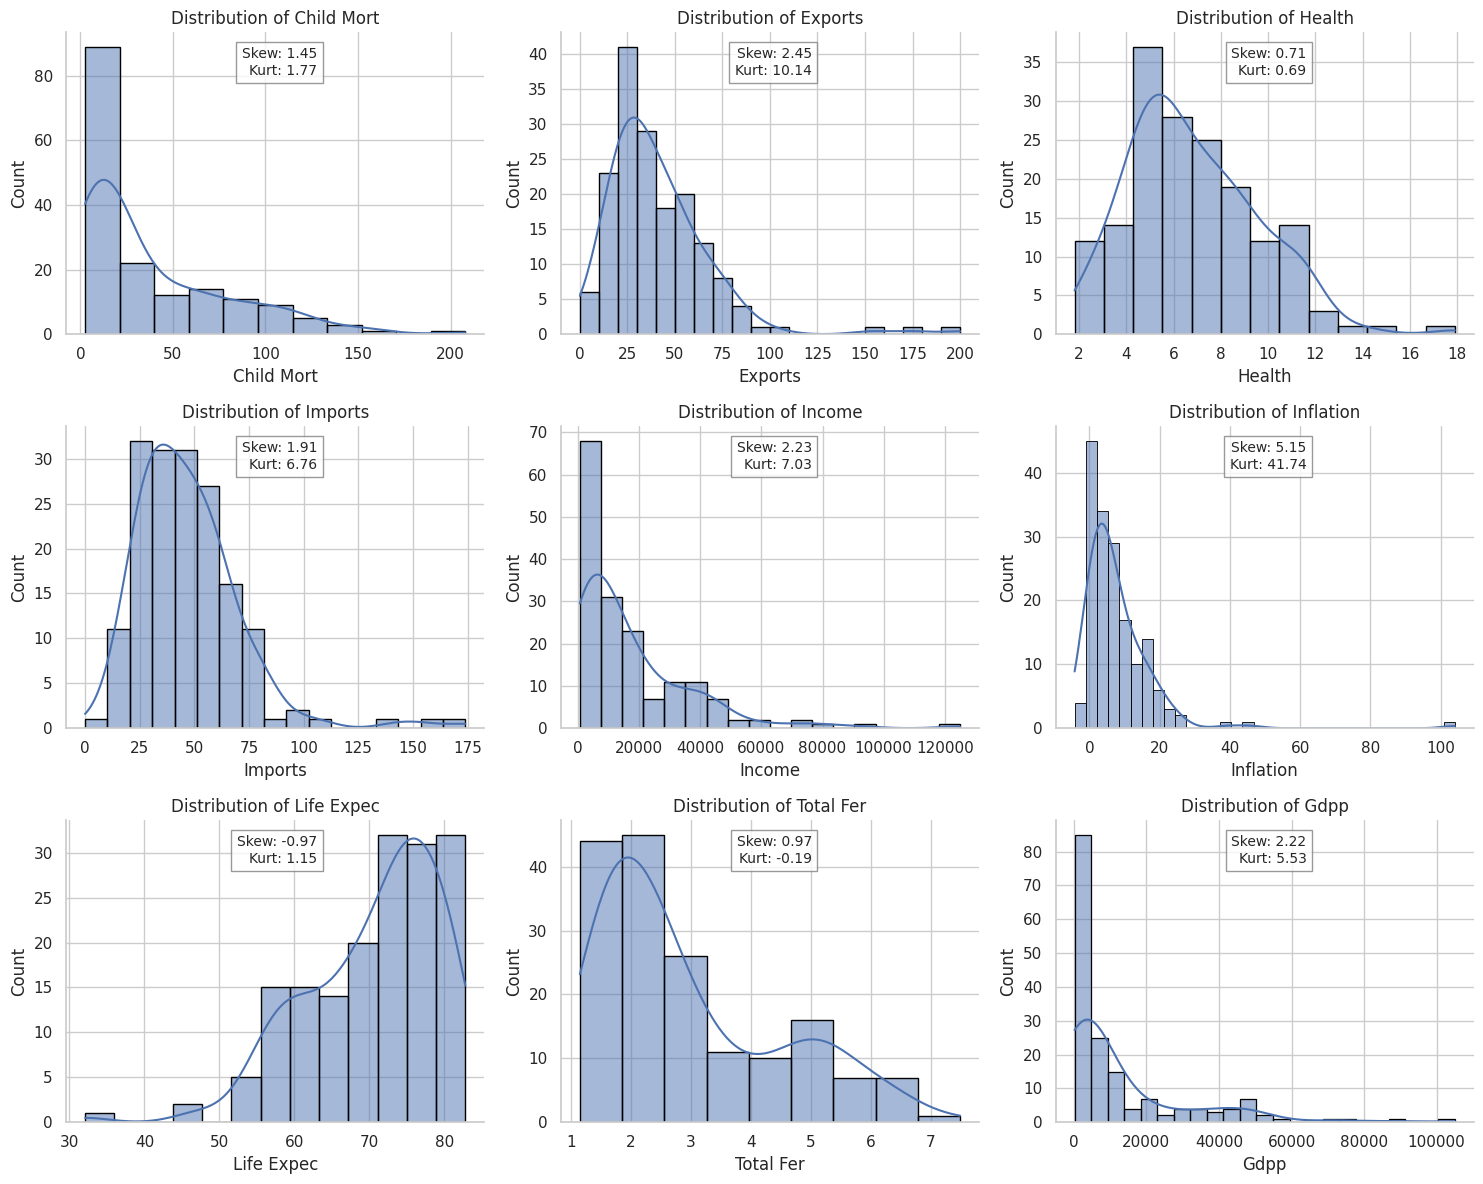

In [ ]:
# dist of numerical cols

num_cols = ['child_mort',	'exports',	'health', 	'imports',	'income',	'inflation'	,
            'life_expec',	'total_fer',	'gdpp']

fig, ax = plt.subplots(3, 3, figsize=(15,12))
plt.subplots_adjust(hspace=0.45, wspace=0.3)

ax = ax.flatten()

for i in range(len(num_cols)):

    col_skew = df[num_cols[i]].skew()
    col_kurt = df[num_cols[i]].kurt()

    sns.histplot(
        data=df, x=num_cols[i],
        edgecolor='black', kde=True,
        ax=ax[i]
    )

    ax[i].set_title(f"Distribution of {num_cols[i].replace('_', ' ').title()}")
    ax[i].set_xlabel(num_cols[i].replace('_', ' ').title())
    ax[i].set_ylabel('Count')

    ax[i].text(
        0.60, 0.95, f"Skew: {col_skew:.2f}\nKurt: {col_kurt:.2f}",
        transform=ax[i].transAxes, ha='right', va='top',
        fontsize=10, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8)
    )

    sns.despine(ax=ax[i])

plt.tight_layout()
plt.show()

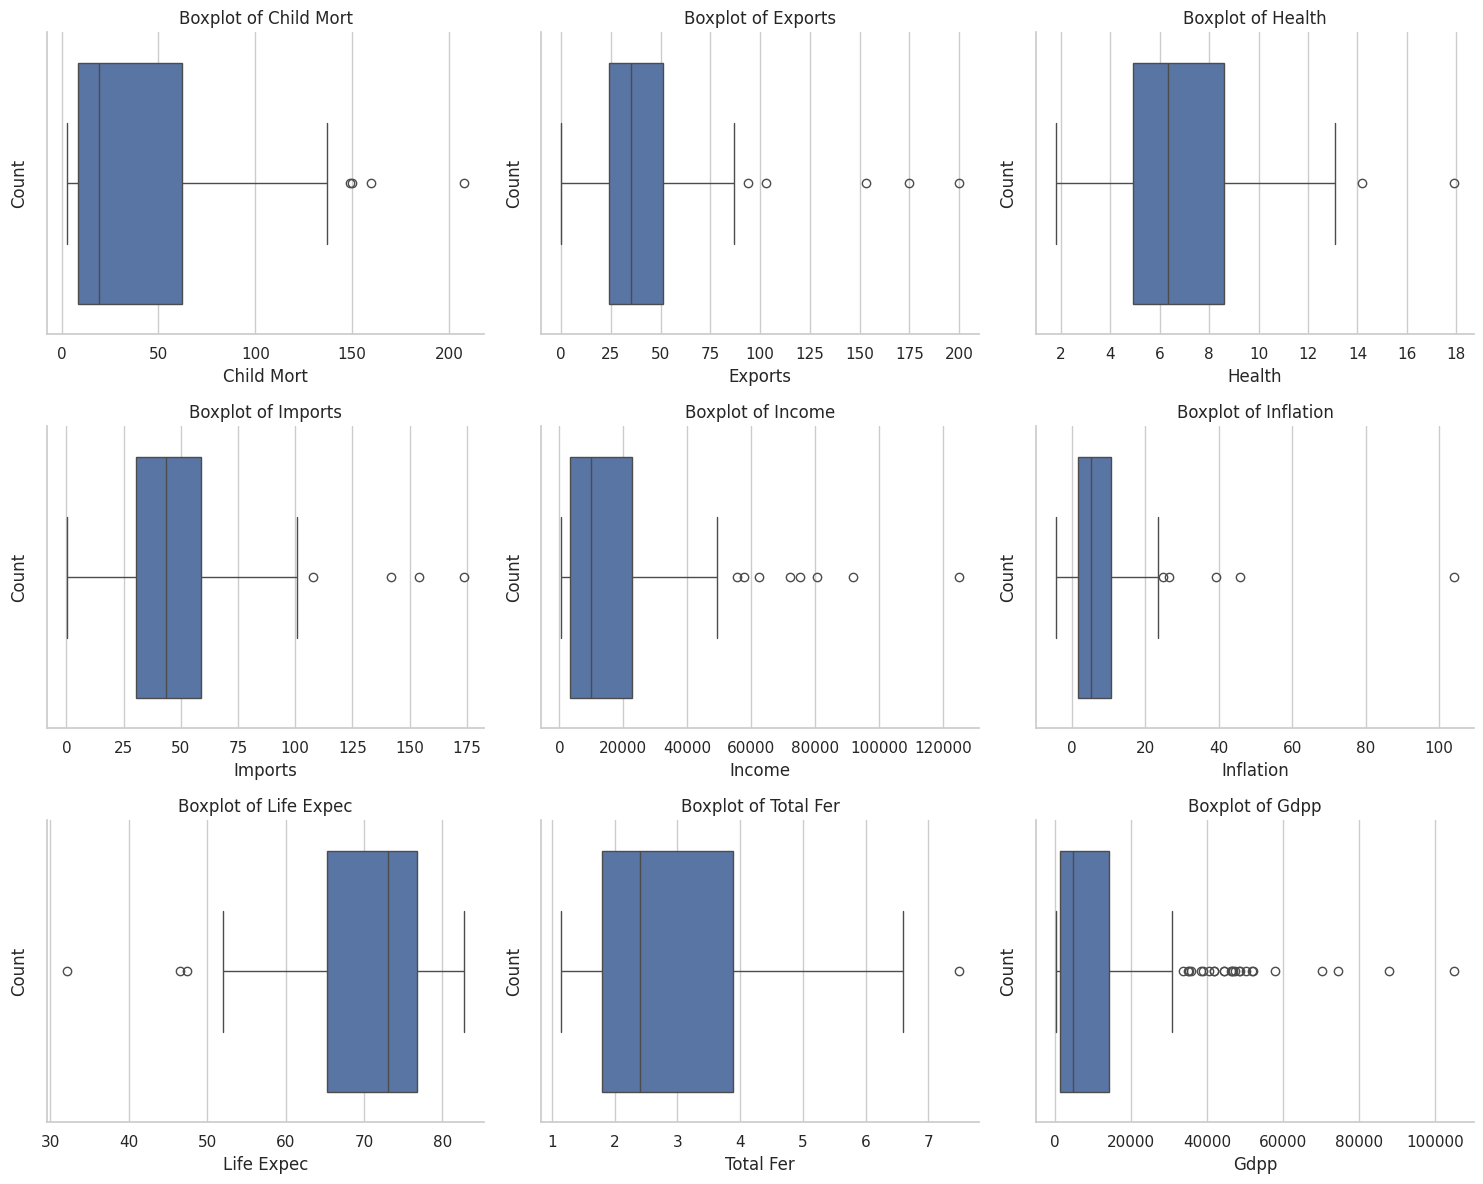

In [ ]:
# outliers

num_cols = ['child_mort',	'exports',	'health', 	'imports',	'income',	'inflation'	,
            'life_expec',	'total_fer',	'gdpp']

fig, ax = plt.subplots(3, 3, figsize=(15,12))
plt.subplots_adjust(hspace=0.45, wspace=0.3)

ax = ax.flatten()

for i in range(len(num_cols)):

    sns.boxplot(
        data=df, x=num_cols[i],
        ax=ax[i]
    )

    ax[i].set_title(f"Boxplot of {num_cols[i].replace('_', ' ').title()}")
    ax[i].set_xlabel(num_cols[i].replace('_', ' ').title())
    ax[i].set_ylabel('Count')

    sns.despine(ax=ax[i])

plt.tight_layout()
plt.show()

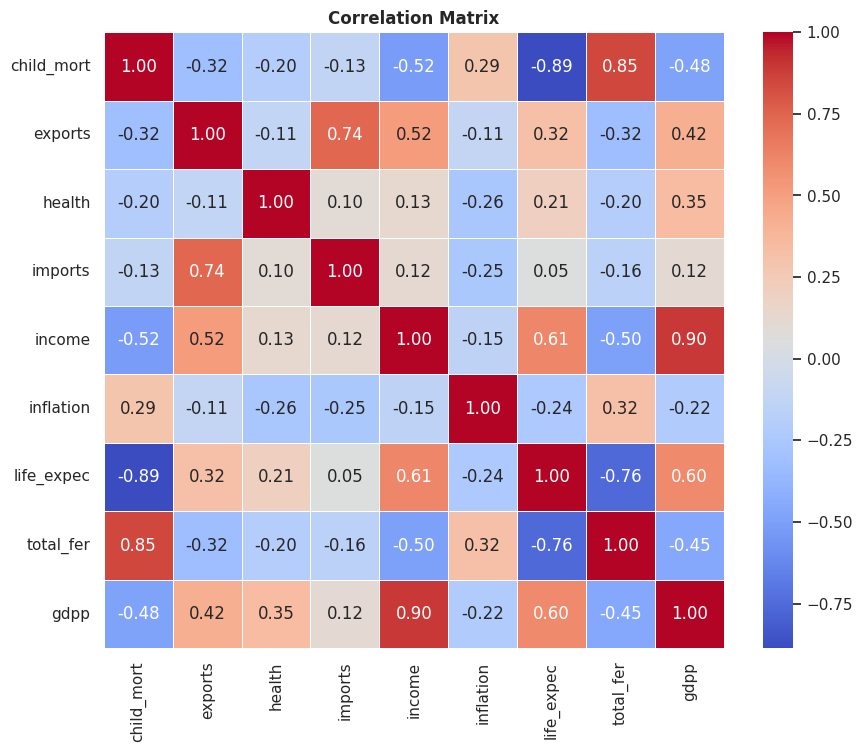

In [ ]:
# heatmap

num_cols = ['child_mort',	'exports',	'health', 	'imports',	'income',	'inflation'	,
            'life_expec',	'total_fer',	'gdpp']

plt.figure(figsize=(10,8))

sns.heatmap(
    df[num_cols].corr(), annot=True,
    cmap='coolwarm', fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix", fontweight='bold');

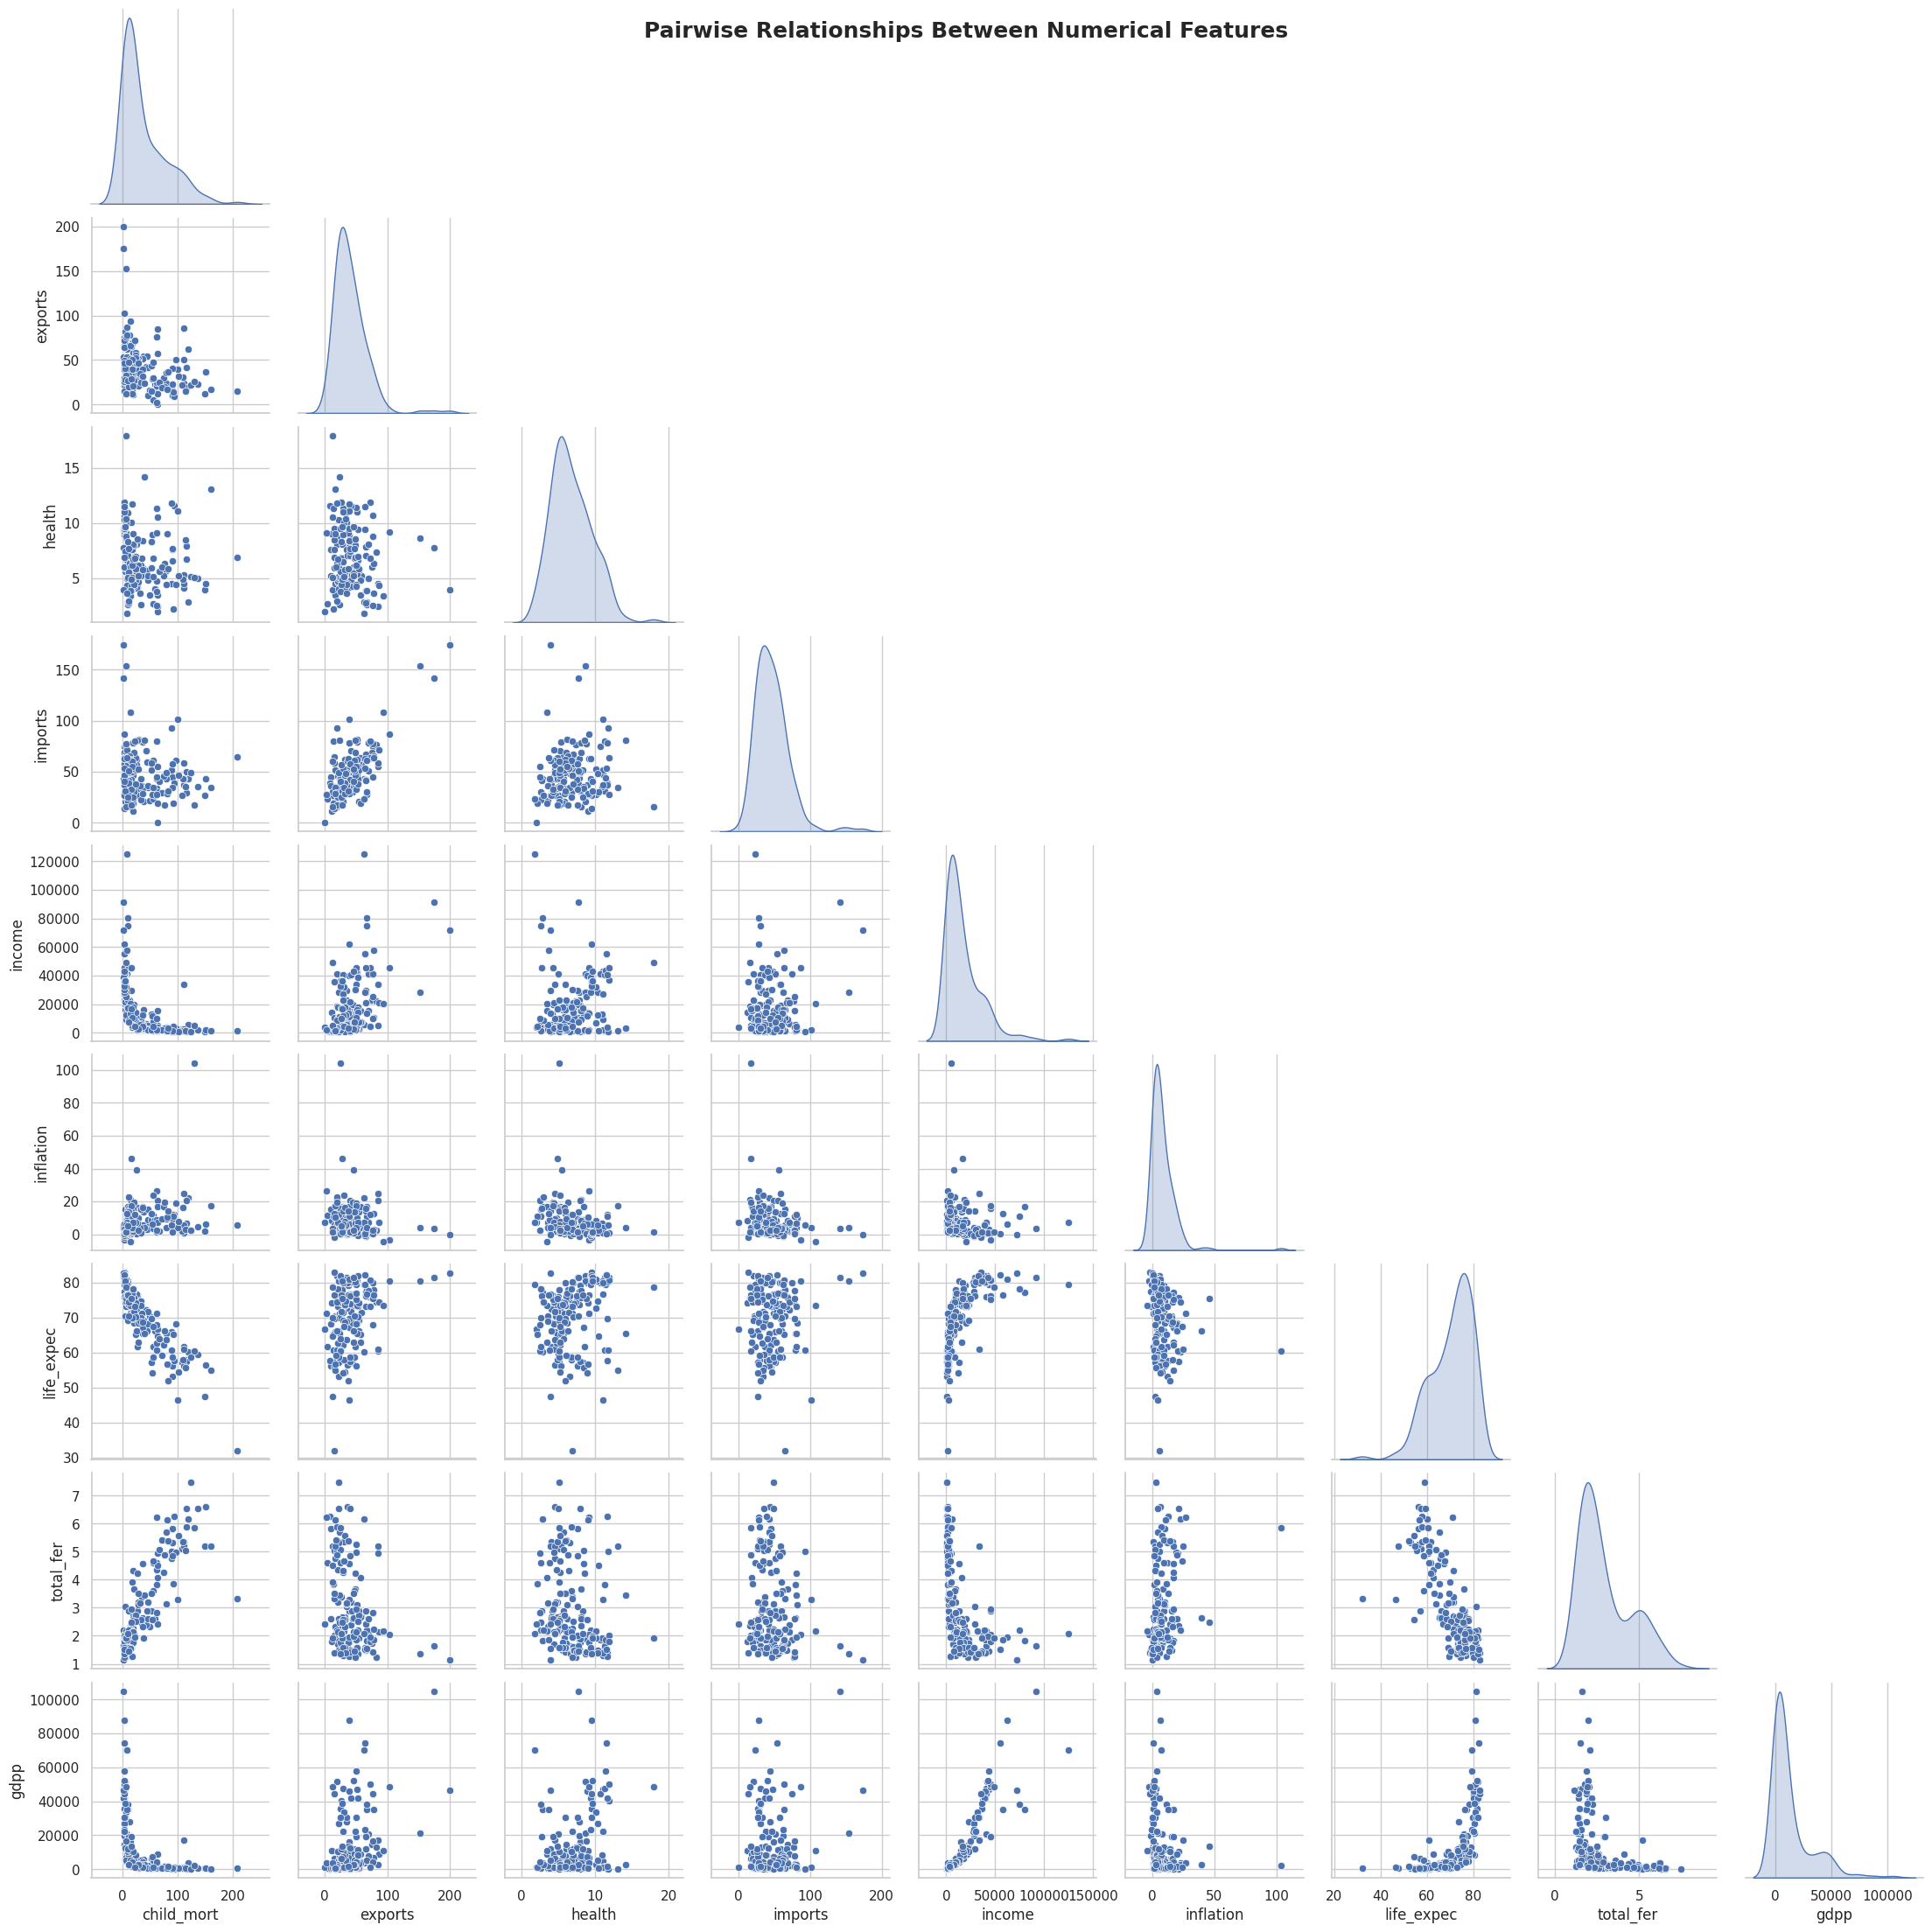

In [ ]:
# pairplots

num_cols = ['child_mort',	'exports',	'health', 	'imports',	'income',	'inflation'	,
            'life_expec',	'total_fer',	'gdpp']

g = sns.pairplot(
    df[num_cols], corner=True, diag_kind="kde",
    height=2.5
)

g.fig.suptitle(
    "Pairwise Relationships Between Numerical Features",
    fontsize=18, fontweight="bold",
)

plt.show()

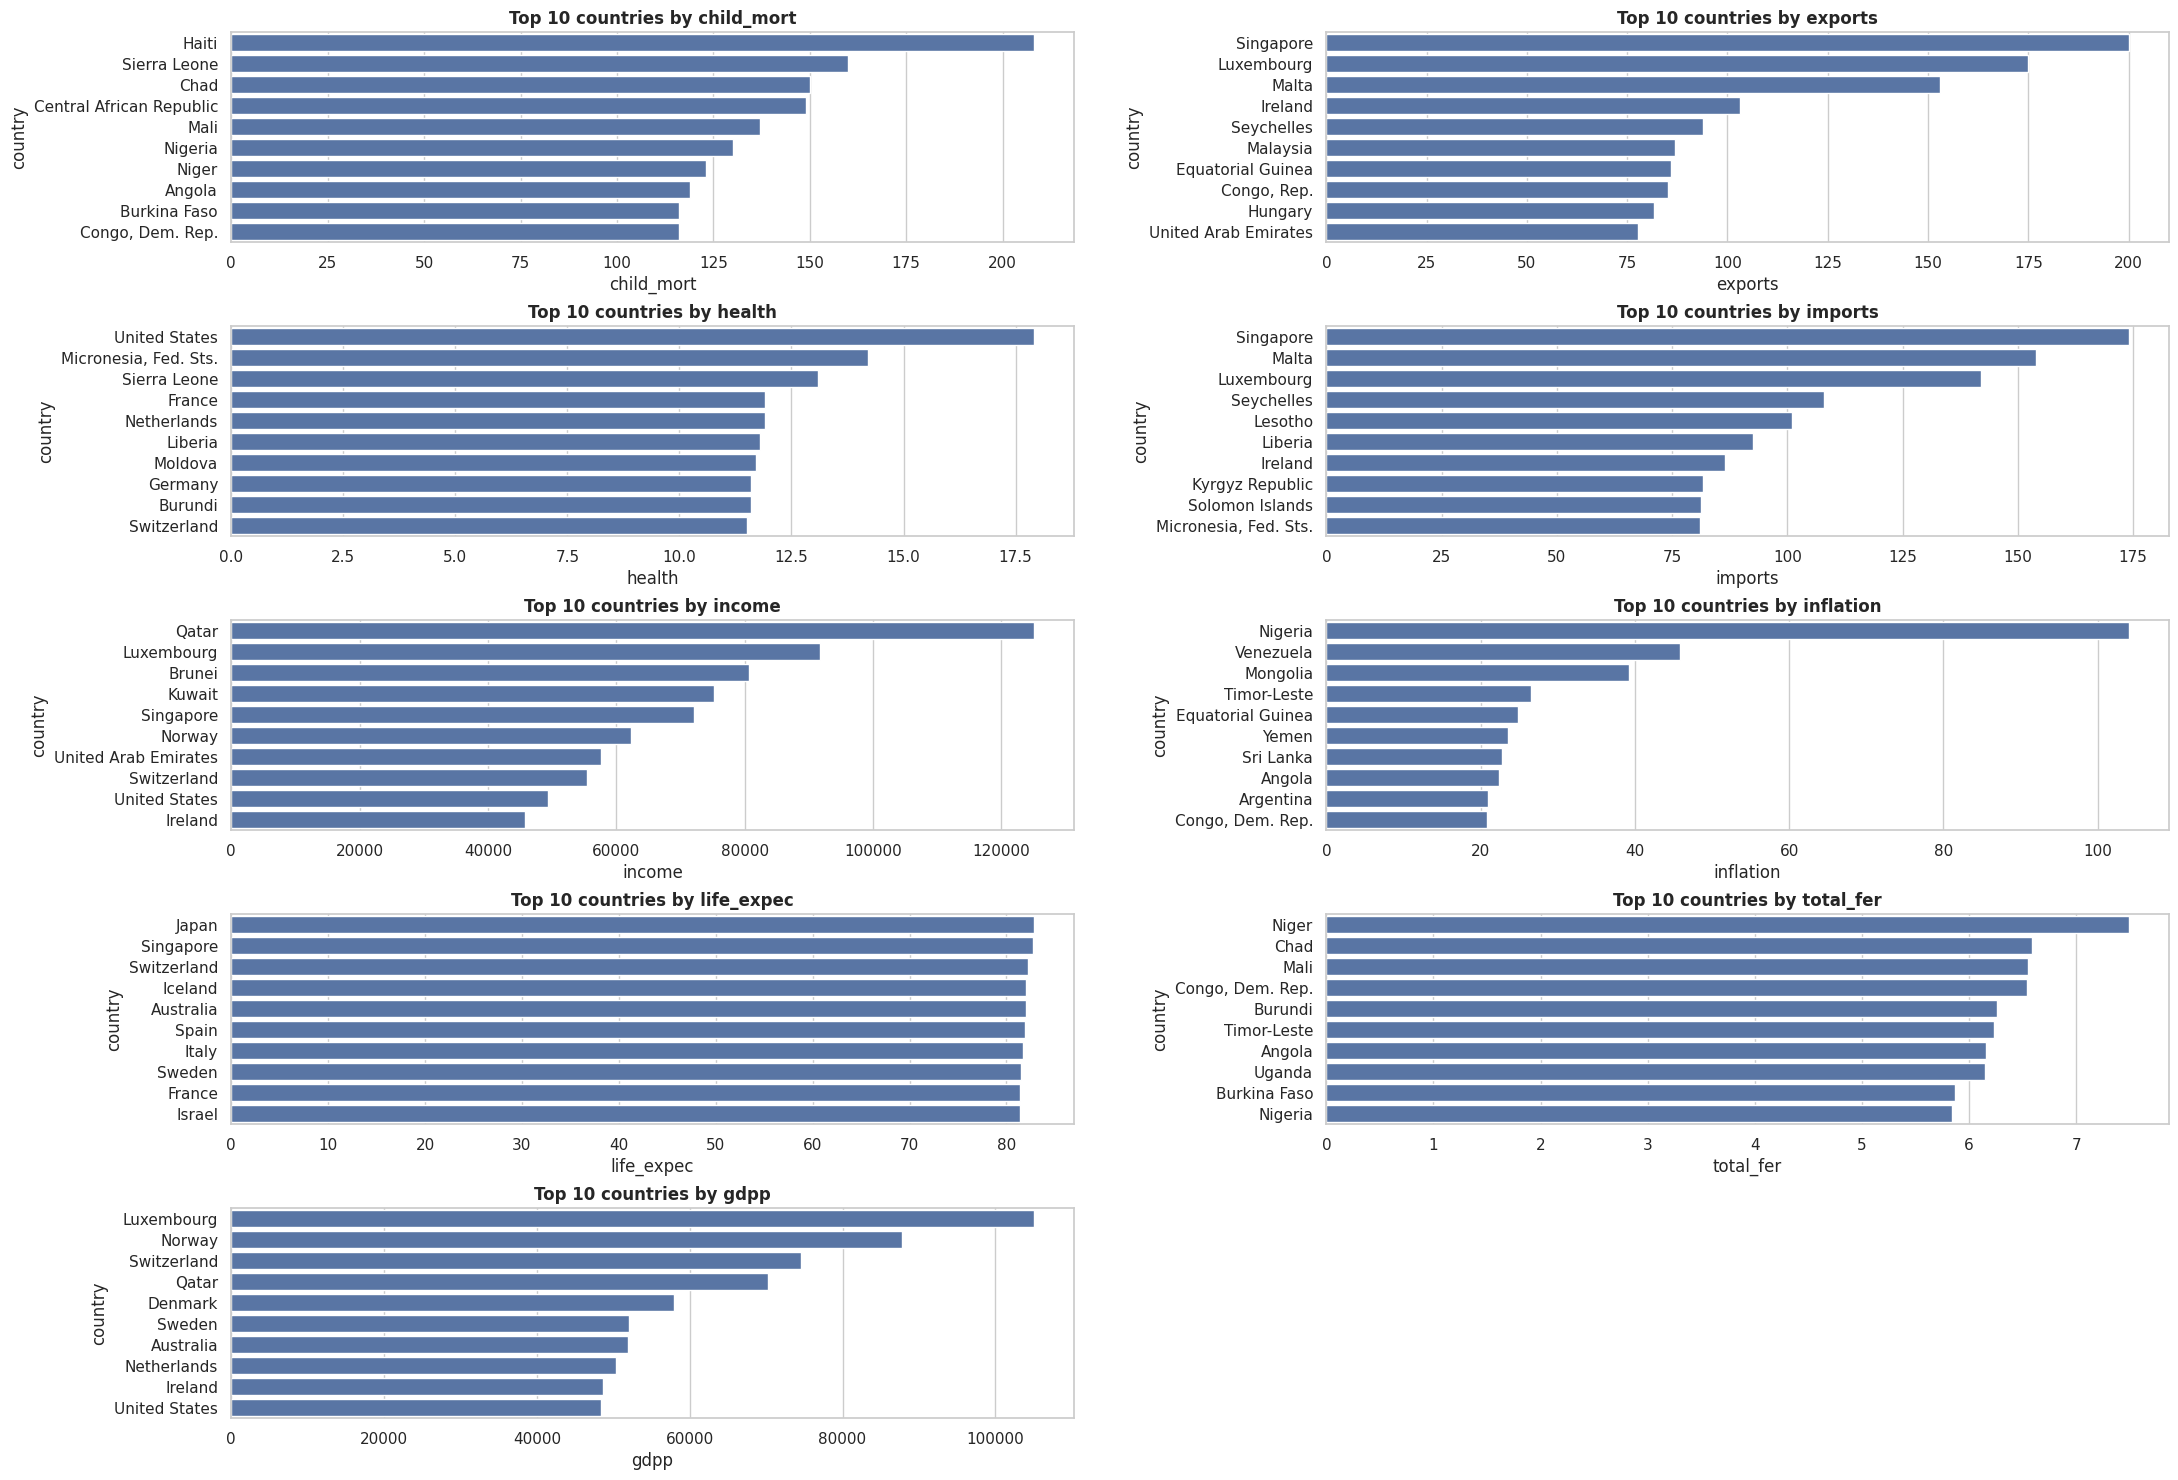

In [ ]:
# data

num_cols = ['child_mort',	'exports', 'health', 'imports','income',	'inflation'	,
            'life_expec',	'total_fer','gdpp']

child_mort_df = df.groupby('country')['child_mort'].mean().reset_index().sort_values(by = 'child_mort', ascending = False).head(10)
exports_df = df.groupby('country')['exports'].mean().reset_index().sort_values(by = 'exports', ascending = False).head(10)
health_df = df.groupby('country')['health'].mean().reset_index().sort_values(by = 'health', ascending = False).head(10)
imports_df = df.groupby('country')['imports'].mean().reset_index().sort_values(by = 'imports', ascending = False).head(10)
income_df = df.groupby('country')['income'].mean().reset_index().sort_values(by = 'income', ascending = False).head(10)
inflation_df = df.groupby('country')['inflation'].mean().reset_index().sort_values(by = 'inflation', ascending = False).head(10)
life_expec_df = df.groupby('country')['life_expec'].mean().reset_index().sort_values(by = 'life_expec', ascending = False).head(10)
total_fer_df = df.groupby('country')['total_fer'].mean().reset_index().sort_values(by = 'total_fer', ascending = False).head(10)
gdpp_df = df.groupby('country')['gdpp'].mean().reset_index().sort_values(by = 'gdpp', ascending = False).head(10)

data_list = [child_mort_df, exports_df, health_df, imports_df ,income_df, inflation_df, life_expec_df ,total_fer_df, gdpp_df]

#-------------------------------------------------------------------------------------

# plot

fig, ax = plt.subplots(5, 2, figsize=(25,18))

plt.subplots_adjust(
    hspace=0.4, wspace=0.3
)

ax = ax.flatten()

for i in range(len(num_cols)):
  sns.barplot(data = data_list[i], x = num_cols[i],  y='country', ax = ax[i]),
  ax[i].set_title(f'Top 10 countries by {num_cols[i]}', fontweight = 'bold', fontsize = 12)

for j in range(len(num_cols), len(ax)):
    fig.delaxes(ax[j])

plt.show();

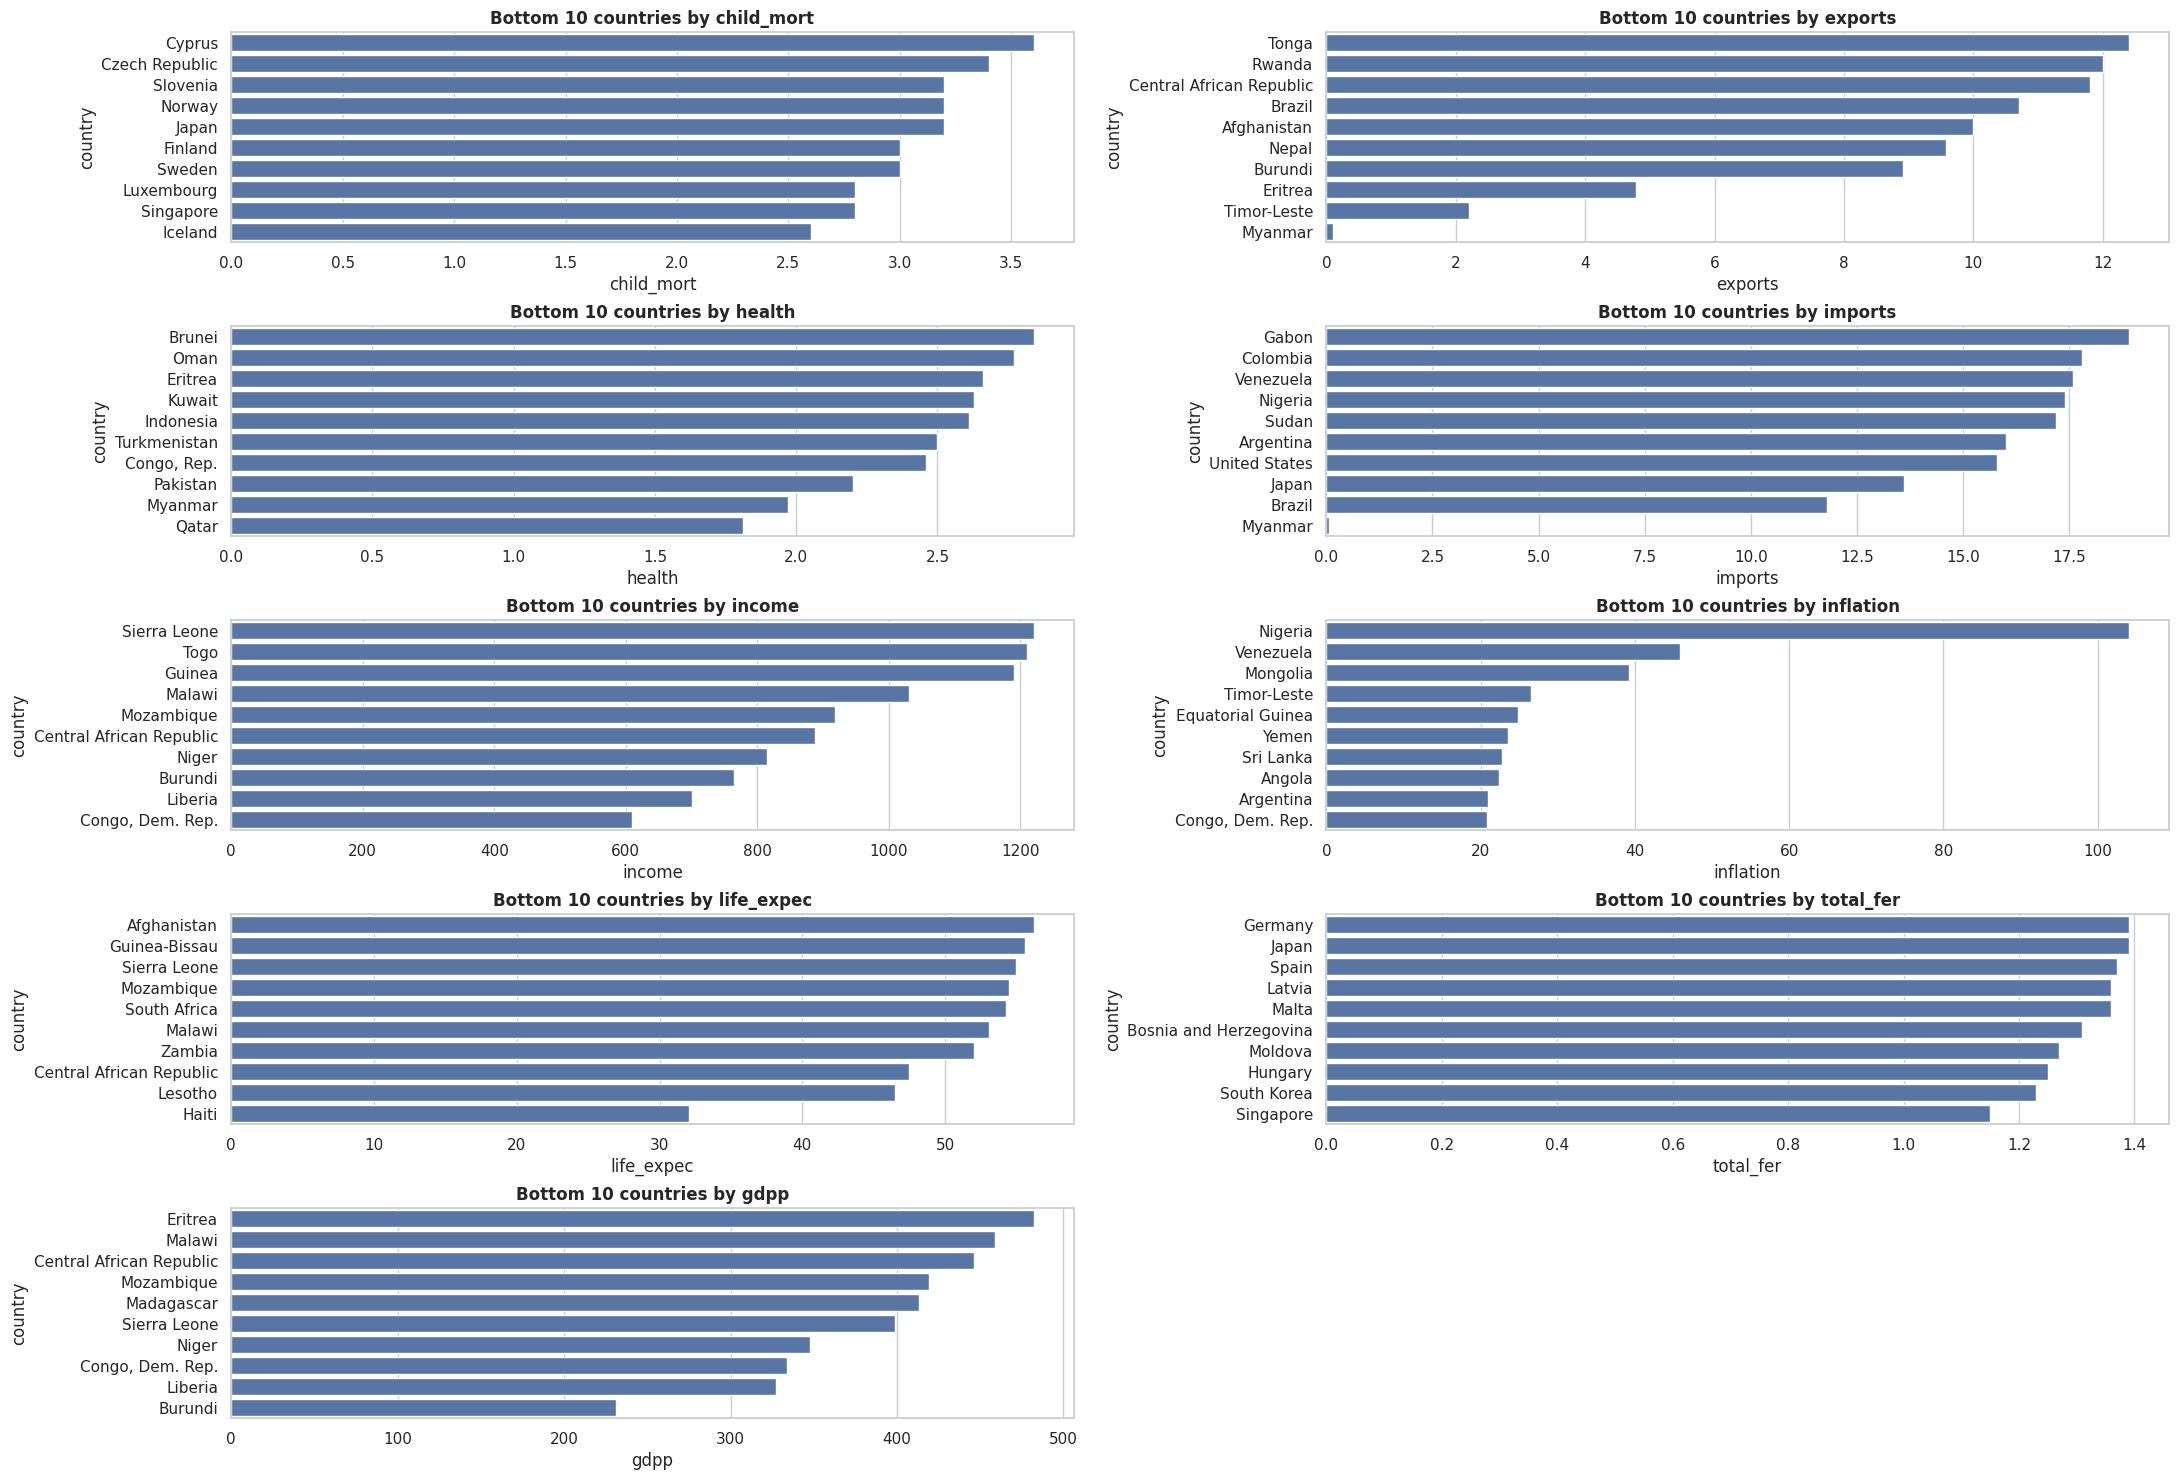

In [ ]:
# data

num_cols = ['child_mort',	'exports', 'health', 'imports','income',	'inflation'	,
            'life_expec',	'total_fer','gdpp']

child_mort_df = df.groupby('country')['child_mort'].mean().reset_index().sort_values(by = 'child_mort', ascending = False).tail(10)
exports_df = df.groupby('country')['exports'].mean().reset_index().sort_values(by = 'exports', ascending = False).tail(10)
health_df = df.groupby('country')['health'].mean().reset_index().sort_values(by = 'health', ascending = False).tail(10)
imports_df = df.groupby('country')['imports'].mean().reset_index().sort_values(by = 'imports', ascending = False).tail(10)
income_df = df.groupby('country')['income'].mean().reset_index().sort_values(by = 'income', ascending = False).tail(10)
inflation_df = df.groupby('country')['inflation'].mean().reset_index().sort_values(by = 'inflation', ascending = False).head(10)
life_expec_df = df.groupby('country')['life_expec'].mean().reset_index().sort_values(by = 'life_expec', ascending = False).tail(10)
total_fer_df = df.groupby('country')['total_fer'].mean().reset_index().sort_values(by = 'total_fer', ascending = False).tail(10)
gdpp_df = df.groupby('country')['gdpp'].mean().reset_index().sort_values(by = 'gdpp', ascending = False).tail(10)

data_list = [child_mort_df, exports_df, health_df, imports_df ,income_df, inflation_df, life_expec_df ,total_fer_df, gdpp_df]

#-------------------------------------------------------------------------------------

# plot

fig, ax = plt.subplots(5, 2, figsize=(25,18))

plt.subplots_adjust(
    hspace=0.4, wspace=0.3
)

ax = ax.flatten()

for i in range(len(num_cols)):
  sns.barplot(data = data_list[i], x = num_cols[i],  y='country', ax = ax[i]),
  ax[i].set_title(f'Bottom 10 countries by {num_cols[i]}', fontweight = 'bold', fontsize = 12)

for j in range(len(num_cols), len(ax)):
    fig.delaxes(ax[j])

plt.show();

# Data Engineering

In [ ]:
df_copy = df.copy()


In [ ]:
num_cols = ['child_mort',	'exports', 'health', 'imports','income',	'inflation'	,
            'life_expec',	'total_fer','gdpp']

for col in num_cols:
  q1 = df_copy[col].quantile(0.25)
  q3 = df_copy[col].quantile(0.75)

  iqr = q3 - q1

  upper = q3 + (1.5 * iqr)
  lower = q1 - (1.5 * iqr)

  outliers = df_copy[(df[col] > upper) | (df_copy[col] < lower)]

  print(f'{col}: {round((len(outliers)/len(df[col])) * 100, 2)}')

child_mort: 2.4
exports: 2.99
health: 1.2
imports: 2.4
income: 4.79
inflation: 2.99
life_expec: 1.8
total_fer: 0.6
gdpp: 14.97


### Outliers Treatment

- Not removing the outliers becuase some countries will have high gdpp and high income. And these do not represent genuine mistakes

In [ ]:
# applying log

df_copy['gdpp'] = np.log1p(df_copy['gdpp'])
df_copy['income'] = np.log1p(df_copy['income'])

In [ ]:
num_cols = ['child_mort',	'exports', 'health', 'imports','income',	'inflation'	,
            'life_expec',	'total_fer','gdpp']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_copy[num_cols])

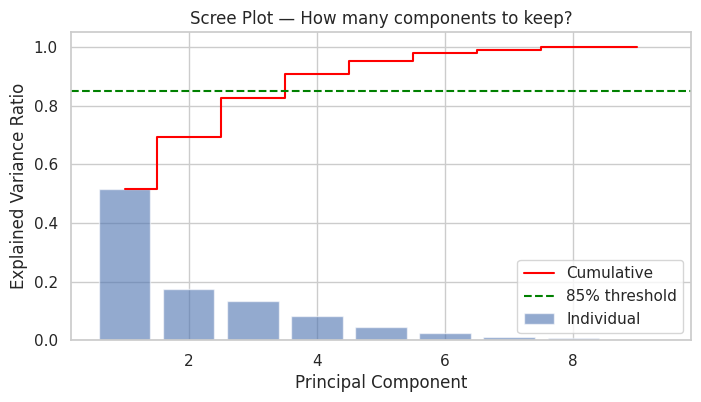

Cumulative variance by component:
  PC1: 51.63%
  PC2: 69.12%
  PC3: 82.43%
  PC4: 90.69%
  PC5: 95.33%
  PC6: 97.94%
  PC7: 98.90%
  PC8: 99.84%
  PC9: 100.00%


In [ ]:
pca_full = PCA()

pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Individual')
plt.step(range(1, len(explained_var)+1), cumulative_var, where='mid', color='red', label='Cumulative')
plt.axhline(y=0.85, color='green', linestyle='--', label='85% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot — How many components to keep?')
plt.legend()
plt.show()

print("Cumulative variance by component:")
for i, v in enumerate(cumulative_var):
    print(f"  PC{i+1}: {v:.2%}")

In [ ]:
n_components = 3

pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape after PCA: {X_pca.shape}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.2%}")

pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df['country'] = df_copy['country'].values

Shape after PCA: (167, 3)
Variance retained: 82.43%


                 PC1       PC2       PC3
child_mort -0.420945  0.127783  0.015976
exports     0.245404  0.614672 -0.217541
health      0.125310 -0.155722  0.676070
imports     0.121037  0.718534  0.179638
income      0.429120 -0.082778 -0.205104
inflation  -0.162714 -0.113698 -0.637944
life_expec  0.416577 -0.168317 -0.060899
total_fer  -0.408222  0.091257 -0.014846
gdpp        0.425944 -0.094185 -0.100553


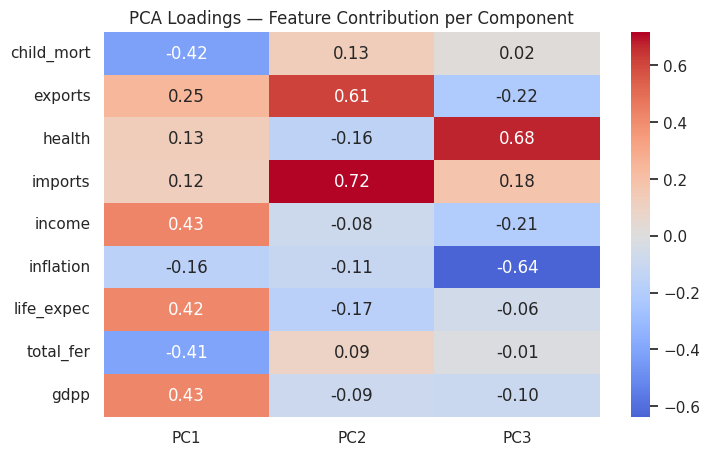

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T, index=num_cols,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print(loadings)

# visualisation
plt.figure(figsize=(8, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('PCA Loadings — Feature Contribution per Component')
plt.show()

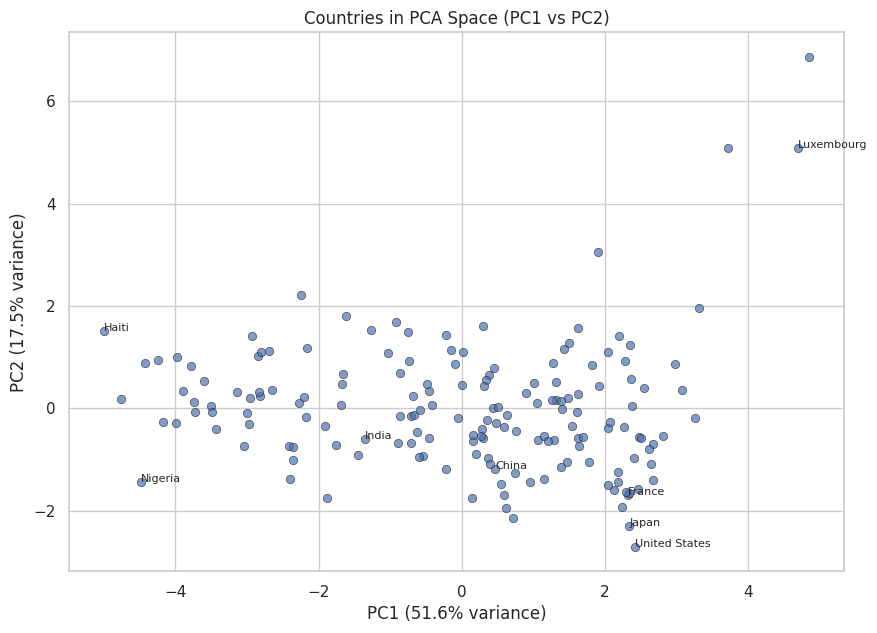

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7, edgecolors='k', linewidths=0.5)


for _, row in pca_df.iterrows():
    if row['country'] in ['United States', 'Nigeria', 'China', 'Haiti', 'Luxembourg', 'India', 'France', 'Japan']:
        plt.annotate(row['country'], (row['PC1'], row['PC2']), fontsize=8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title('Countries in PCA Space (PC1 vs PC2)')
plt.show()

# KMeans

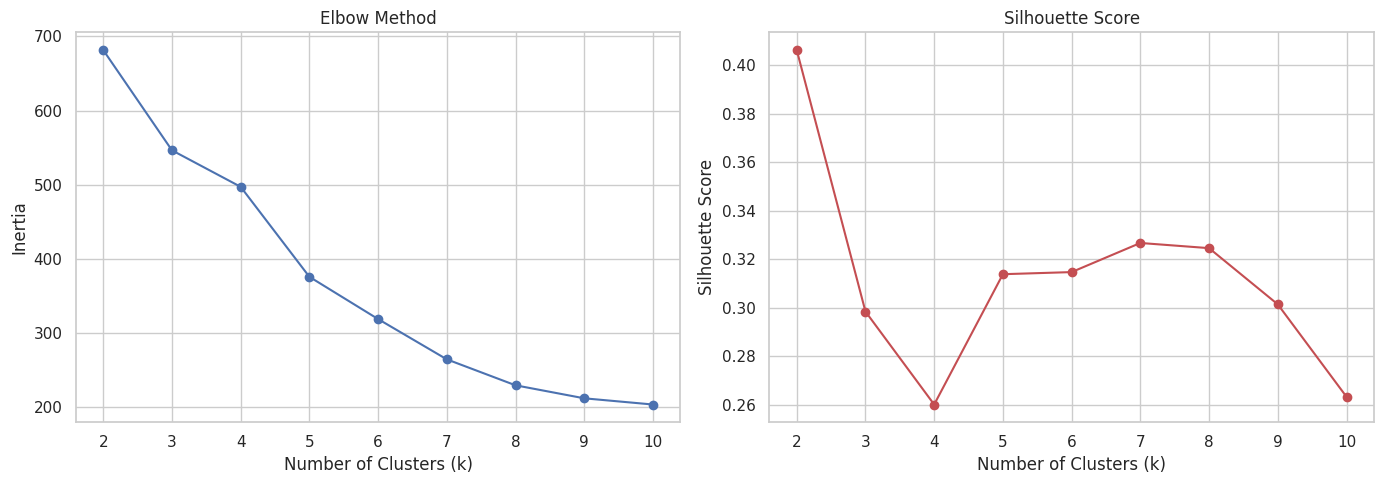

In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
  km = KMeans(n_clusters = k, random_state = 42, n_init='auto')
  km.fit(X_pca)
  inertia.append(km.inertia_)
  silhouette_scores.append(silhouette_score(X_pca, km.labels_))


# plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# inertia
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

# silhouette_scores
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()



In [ ]:
# fitting kmeans with the best k

optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_pca)
pca_df['kmeans_cluster'] = kmeans_labels

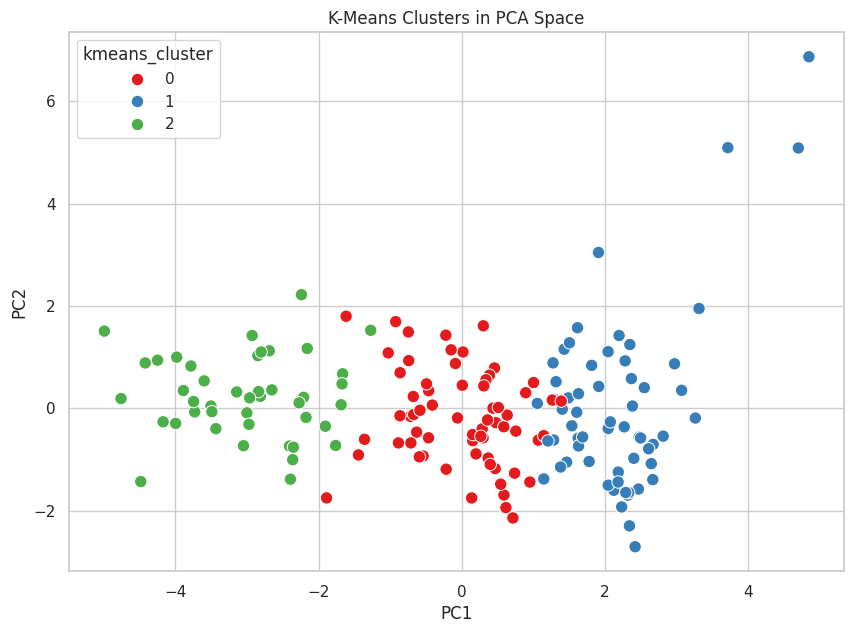

In [ ]:
# visualise clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='kmeans_cluster', palette='Set1', s=80)
plt.title('K-Means Clusters in PCA Space')
plt.show()

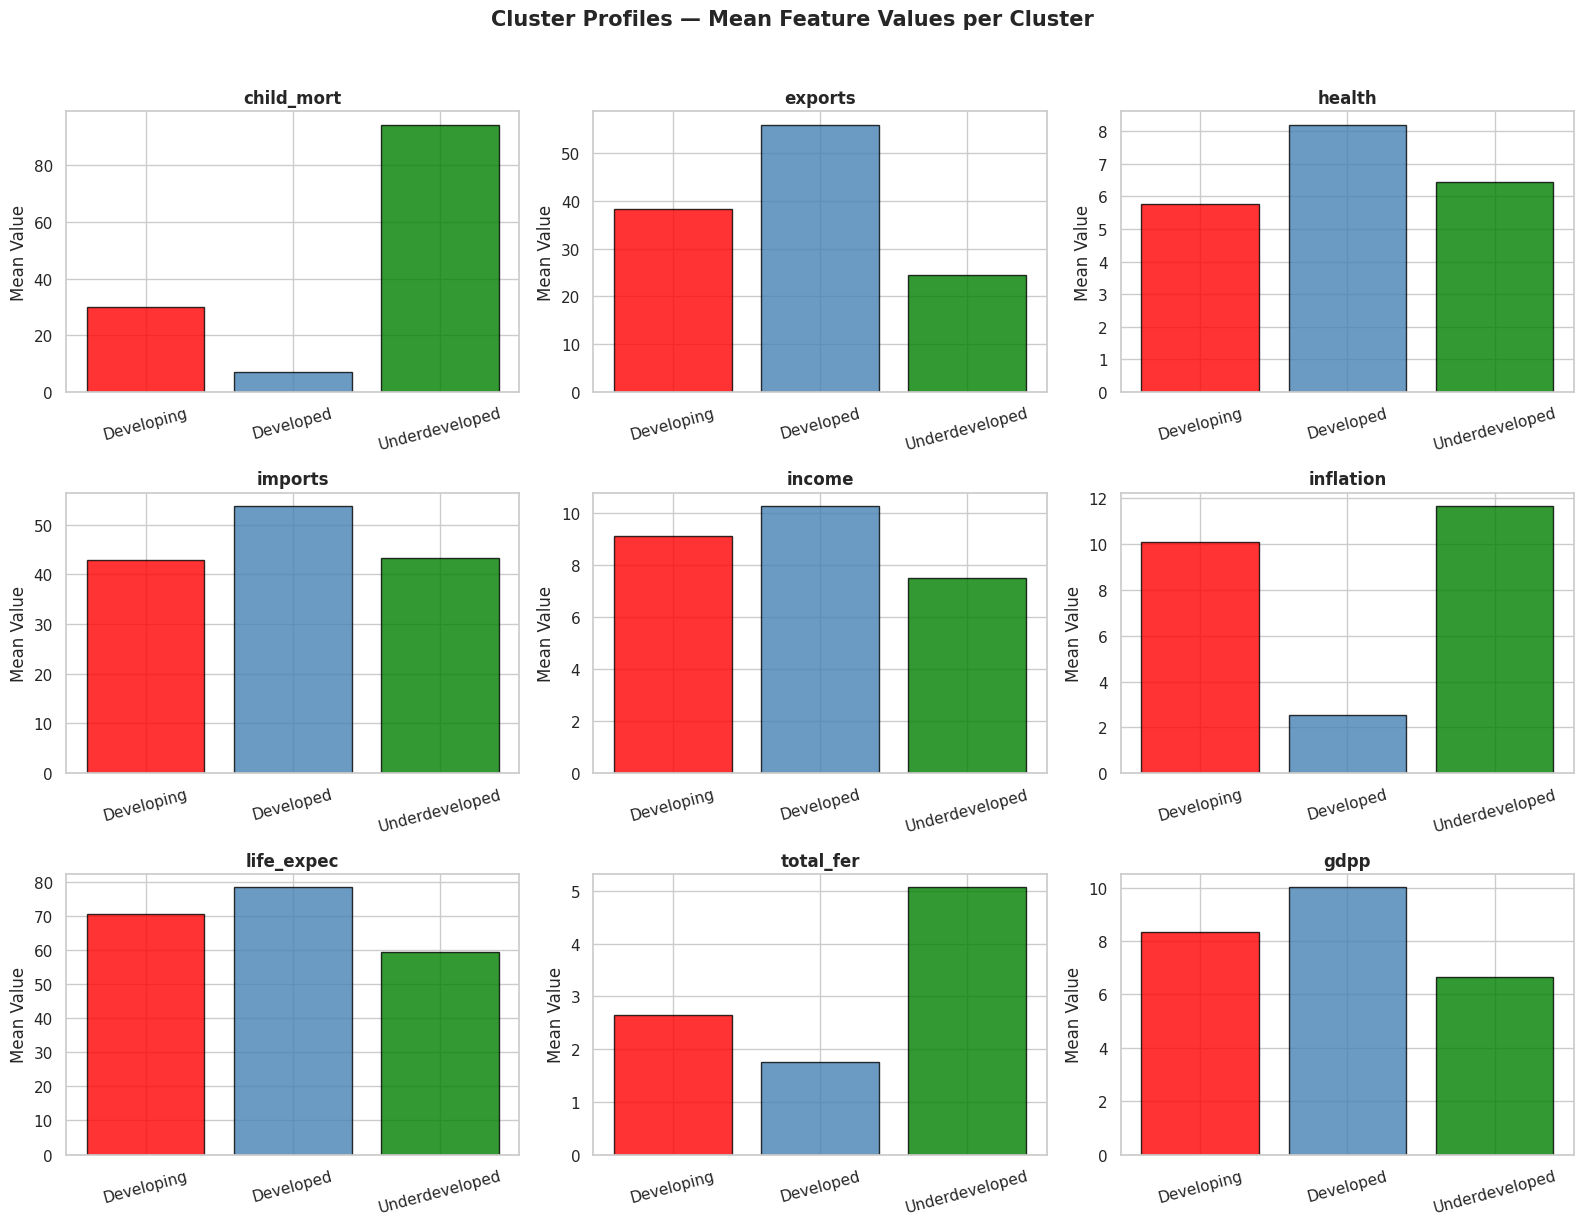

In [ ]:
# cluster profile

df_copy['kmeans_cluster'] = kmeans_labels

cluster_profile = df_copy.groupby('kmeans_cluster')[num_cols].mean().round(2)

# Visualize cluster profiles
cluster_profile_plot = cluster_profile.copy()
cluster_profile_plot.index = ['Developing', 'Developed', 'Underdeveloped']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].bar(cluster_profile_plot.index, cluster_profile_plot[col],
                color=['red', 'steelblue', 'green'], edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Mean Value')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Cluster Profiles — Mean Feature Values per Cluster', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
for cluster in sorted(df_copy['kmeans_cluster'].unique()):
    countries = df_copy[df_copy['kmeans_cluster'] == cluster]['country'].values
    print(f"\nCluster {cluster} ({len(countries)} countries):")
    print(countries[:10])


Cluster 0 (64 countries):
['Albania' 'Algeria' 'Argentina' 'Armenia' 'Azerbaijan' 'Bangladesh'
 'Belarus' 'Belize' 'Bhutan' 'Bolivia']

Cluster 1 (60 countries):
['Antigua and Barbuda' 'Australia' 'Austria' 'Bahamas' 'Bahrain'
 'Barbados' 'Belgium' 'Bosnia and Herzegovina' 'Brunei' 'Bulgaria']

Cluster 2 (43 countries):
['Afghanistan' 'Angola' 'Benin' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.']


In [ ]:
cluster_labels_map = {
    0: 'Developing',
    1: 'Developed',
    2: 'Underdeveloped'
}

df_copy['kmeans_segment'] = df_copy['kmeans_cluster'].map(cluster_labels_map)

## K-Means Summary

- Optimal clusters selected: **k=3** based on Elbow Method and Silhouette Score
- **Cluster 0 (Developing):** Middle-income countries with moderate child mortality,
  average life expectancy and gdpp. Mix of Asian, Latin American and Eastern European nations.
- **Cluster 1 (Developed):** High income, high gdpp, high life expectancy, low child
  mortality. Mostly Western European, North American and East Asian nations.
- **Cluster 2 (Underdeveloped):** Low income, low gdpp, high child mortality, high
  fertility rate. Predominantly Sub-Saharan African nations.
- K-Means produced **balanced, evenly sized clusters** making it easy to interpret
  and suitable for policy segmentation.

# Hierarchical Clustering

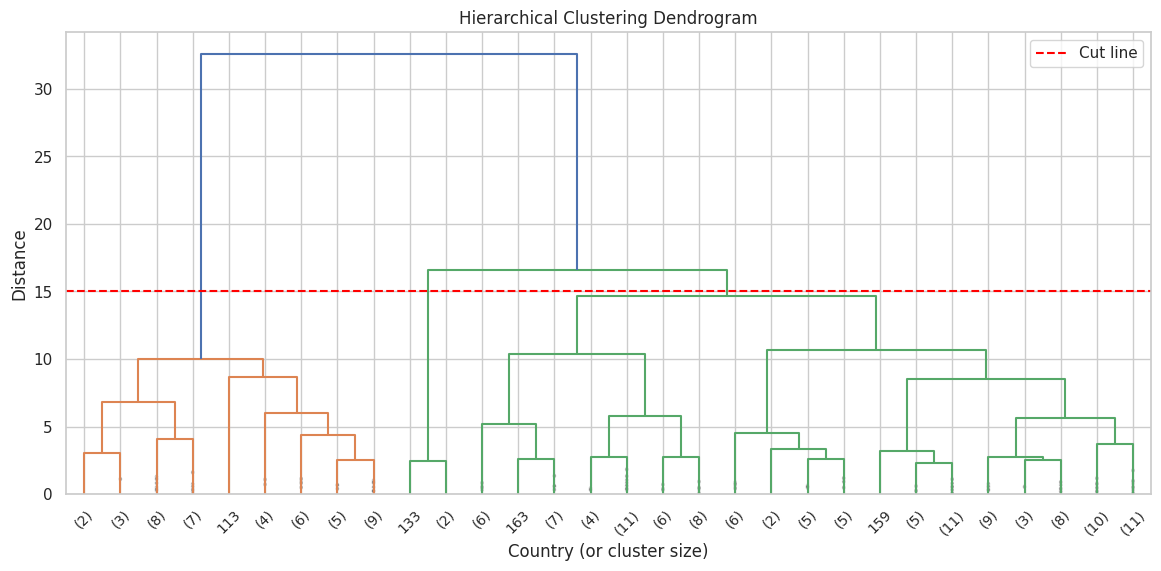

In [ ]:
linked = linkage(X_pca, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Country (or cluster size)')
plt.ylabel('Distance')
plt.axhline(y=15, color='red', linestyle='--', label='Cut line')
plt.legend()
plt.show()

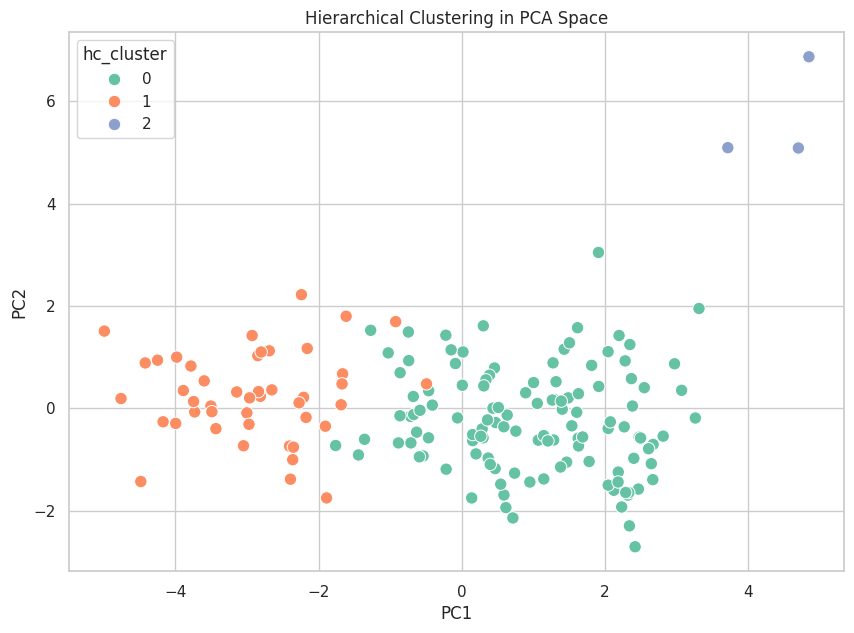

In [ ]:
# Best k = 3
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X_pca)
pca_df['hc_cluster'] = hc_labels

# Step 3 - Visualize
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                hue='hc_cluster', palette='Set2', s=80)
plt.title('Hierarchical Clustering in PCA Space')
plt.show()

## Hierarchical Clustering Summary

- Used **Ward linkage** method with dendrogram cut at distance=15
- Dendrogram clearly showed **3 natural groups** confirmed by a large gap
  between merges at y=15 and y=32
- **Cluster 1 (Underdeveloped):** Matches K-Means underdeveloped group closely
- **Cluster 0 (Developing + Developed):** Merged into one large cluster unlike K-Means
- **Cluster 2 (Trade Outliers):** Isolated extreme trade-dependent wealthy nations
  (Luxembourg, Singapore, Malta) as a separate tiny cluster

# DBSCAN

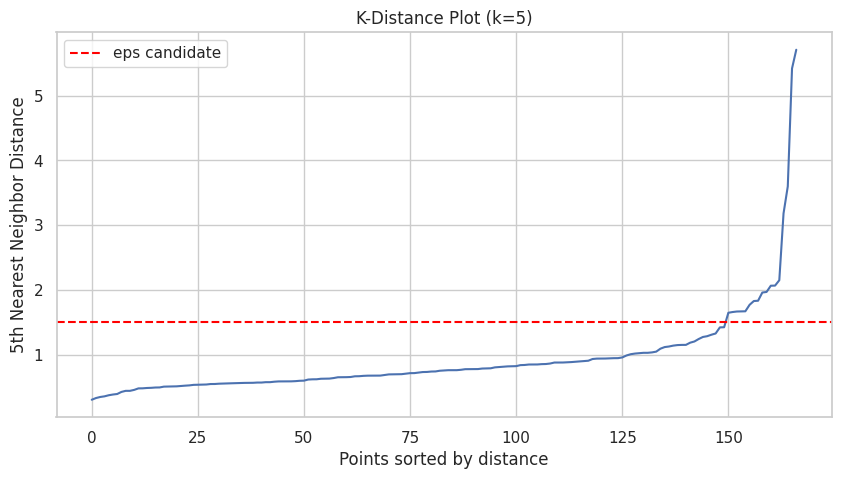

In [ ]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_pca)
distances, indices = neighbors.kneighbors(X_pca)

# Sort distances to 5th nearest neighbor
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Plot (k=5)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps candidate')
plt.legend()
plt.show()

In [ ]:
for eps_val in [0.8, 0.85, 0.9, 0.95]:
    db = DBSCAN(eps=eps_val, min_samples=5)
    labs = db.fit_predict(X_pca)
    n_clusters = len(set(labs)) - (1 if -1 in labs else 0)
    n_noise = list(labs).count(-1)
    print(f"eps={eps_val} → Clusters: {n_clusters}, Noise: {n_noise}")

eps=0.8 → Clusters: 3, Noise: 40
eps=0.85 → Clusters: 3, Noise: 33
eps=0.9 → Clusters: 2, Noise: 24
eps=0.95 → Clusters: 1, Noise: 22


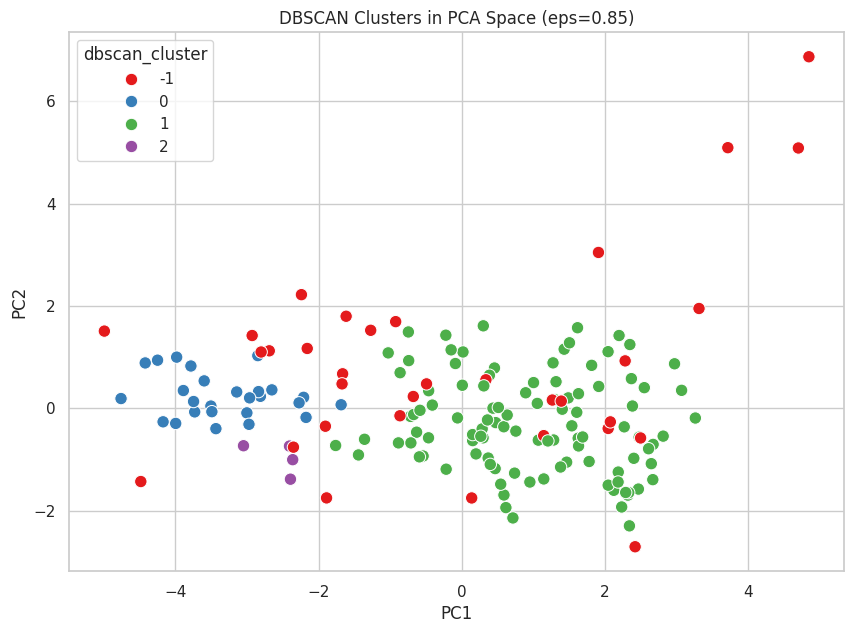


Noise countries (33):
['Angola' 'Brunei' 'Congo, Rep.' 'Equatorial Guinea' 'Gabon' 'Haiti'
 'Ireland' 'Kiribati' 'Kuwait' 'Lao' 'Lesotho' 'Liberia' 'Libya'
 'Luxembourg' 'Malta' 'Mauritania' 'Micronesia, Fed. Sts.' 'Moldova'
 'Mongolia' 'Myanmar' 'Nigeria' 'Oman' 'Qatar' 'Rwanda' 'Saudi Arabia'
 'Seychelles' 'Singapore' 'Solomon Islands' 'Togo' 'United Arab Emirates'
 'United States' 'Venezuela' 'Yemen']


In [ ]:
dbscan = DBSCAN(eps=0.85, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
pca_df['dbscan_cluster'] = dbscan_labels

# visualize
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                hue='dbscan_cluster', palette='Set1', s=80)
plt.title('DBSCAN Clusters in PCA Space (eps=0.85)')
plt.show()

# list noise countries
noise_countries = df_copy[dbscan_labels == -1]['country'].values
print(f"\nNoise countries ({len(noise_countries)}):")
print(noise_countries)

## DBSCAN Summary

- Optimal parameters selected: **eps=0.85, min_samples=5** based on K-Distance Plot
- Produced **3 clusters** with **33 noise points (-1)**
- **Cluster 0 (Underdeveloped):** Low PC1 countries, matches other methods
- **Cluster 1 (Developing + Developed):** Large cluster covering middle to high PC1
- **Cluster 2:** Small group of borderline countries
- **33 noise countries** identified — not errors but genuinely atypical economies:
  - Oil-rich Gulf states: Qatar, UAE, Kuwait, Saudi Arabia
  - Micro/island economies: Singapore, Luxembourg, Malta, Kiribati
  - Conflict/instability affected: Haiti, Yemen, Liberia


# Comparision Report

In [ ]:
mask = dbscan_labels != -1

metrics = {
    'Silhouette Score': [
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, hc_labels),
        silhouette_score(X_pca[mask], dbscan_labels[mask])
    ],
    'Davies-Bouldin Index': [
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, hc_labels),
        davies_bouldin_score(X_pca[mask], dbscan_labels[mask])
    ],
    'Calinski-Harabasz Index': [
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, hc_labels),
        calinski_harabasz_score(X_pca[mask], dbscan_labels[mask])
    ]
}

metrics_df = pd.DataFrame(metrics, index=['K-Means', 'Hierarchical', 'DBSCAN'])
print(metrics_df.round(3))

              Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
K-Means                  0.299                 1.196                  103.987
Hierarchical             0.447                 0.690                   95.946
DBSCAN                   0.378                 0.727                   90.039


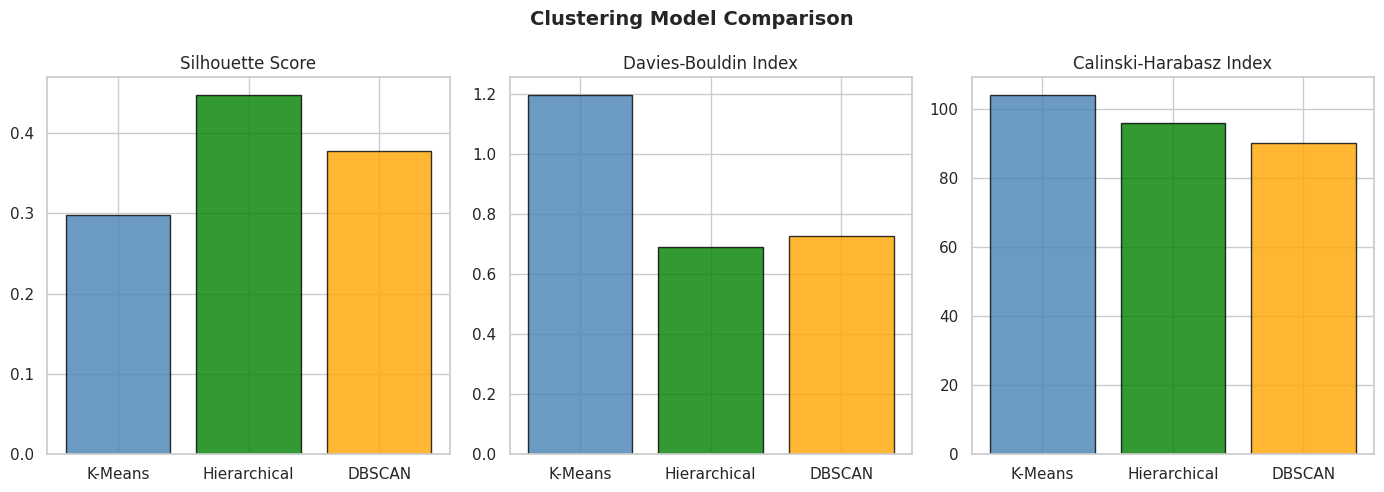

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, metric in enumerate(metrics_df.columns):
    axes[i].bar(metrics_df.index, metrics_df[metric],
                color=['steelblue', 'green', 'orange'], edgecolor='black', alpha=0.8)
    axes[i].set_title(metric)
plt.suptitle('Clustering Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Results & Recommendations

## Key Findings from Clustering Analysis

The clustering analysis successfully identified **3 distinct country segments**
using K-Means, Hierarchical, and DBSCAN on PCA-reduced socio-economic data
from 167 countries.

K-Means was selected as the best performing model overall based on the
Calinski-Harabasz Index (103.987) and its ability to produce balanced,
interpretable clusters suitable for policy segmentation.

---

## Segment Profiles

### Segment 1 — Underdeveloped Nations (43 countries)
Examples: Afghanistan, Angola, Benin, Burkina Faso, Burundi, Chad

**Profile:**
- Highest child mortality rates
- Lowest income and gdpp
- Highest fertility rates (total_fer)
- Lowest life expectancy
- Minimal exports and health spending

**Business Interpretation:**
These countries represent the highest-risk, lowest-return markets.
They lack basic infrastructure and human capital needed for economic
participation. International organizations (World Bank, IMF, UN) should
prioritize these nations for aid and intervention.

**Policy Recommendations:**
- Invest heavily in maternal and child healthcare to reduce child mortality
- Introduce family planning and education programs to manage fertility rates
- Provide debt relief and foreign aid to stimulate basic economic activity
- Build foundational infrastructure — clean water, sanitation, electricity
- Partner with NGOs for grassroots healthcare and education delivery

---

### Segment 2 — Developing Nations (64 countries)
Examples: Albania, Algeria, Argentina, Armenia, Bangladesh, Bolivia

**Profile:**
- Middle-range income and gdpp
- Moderate child mortality
- Average life expectancy
- Moderate exports and imports
- Some inflation volatility

**Business Interpretation:**
These are emerging markets with significant growth potential. They represent
the largest segment (64 countries) and are the most attractive for foreign
direct investment, trade partnerships, and market expansion strategies.

**Policy Recommendations:**
- Diversify exports to move up the economic value chain
- Increase health expenditure as % of GDP to further improve life expectancy
- Implement stable monetary policies to control inflation and attract investors
- Invest in higher education and vocational training for skilled workforce development
- Strengthen trade agreements with developed nations to boost economic integration

---

### Segment 3 — Developed Nations (60 countries)
Examples: Australia, Austria, Bahamas, Belgium, Barbados

**Profile:**
- Highest income and gdpp
- Lowest child mortality
- Highest life expectancy
- Strong export and import activity
- High health expenditure

**Business Interpretation:**
These are stable, high-return markets with strong institutions and purchasing
power. They are best suited for premium products, technology investment, and
innovation partnerships. They also have a responsibility to support lower
segments through trade and aid policies.

**Policy Recommendations:**
- Sustain high healthcare spending to maintain low child mortality and aging population health
- Lead global climate and sustainability financing for underdeveloped nations
- Use trade agreements and FDI to support developing nations' economic growth
- Address within-country inequality despite high average gdpp
- Serve as innovation hubs — invest in R&D, green energy, and digital infrastructure

